In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Methods lab — Two different rows can contain the same evidence

## What is the object of evaluation?

An array has rows, but the scientific unit might be a person, a physical object, a manufacturing batch, a camera session, or a time interval. A splitter that keeps row numbers apart has not necessarily kept independent units apart. This lab makes that distinction visible without inventing a new observed dataset.

We begin with the 210 observed Seeds feature vectors. Then we deliberately make three exact software copies of each row. There are now 630 array rows but still only 210 source kernels. These copies are a **manufactured leakage stress test**. They are not additional measurements, repeatability trials, new kernels, or a larger agricultural study.

The repeated source ID is the unit key. Generated copy IDs distinguish software rows. Saving both makes it possible to ask two questions independently: are array indices shared, and are source kernels shared?



In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/shape_lab').is_dir())
if str(ROOT / 'src') not in sys.path: sys.path.insert(0, str(ROOT / 'src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shape_lab.evidence_v7 import load_snapshot, conformal_rank, conformal_radius, coverage, overlap_report
from shape_lab.display import show_and_save, save_json

OUT=ROOT/'reports/v7/leakage';OUT.mkdir(parents=True,exist_ok=True)
table,meta=load_snapshot('seeds')
X=table[meta['features']].to_numpy();y=table.variety.to_numpy()
# These copies are a manufactured stress test, not new observed kernels.
Xcopy=np.repeat(X,3,axis=0);ycopy=np.repeat(y,3);unit=np.repeat(table.source_id.to_numpy(),3)
print('Observed kernels:',len(X),'constructed rows:',len(Xcopy))


Observed kernels: 210 constructed rows: 630


## Disjoint array rows can share the same source
Compare randomized row assignment to a group split on kernel IDs. The group split evaluates new source kernels in this collection, not new farms.

In [3]:
from sklearn.model_selection import train_test_split,GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
rows=np.arange(len(Xcopy))
a,b=train_test_split(rows,test_size=.3,random_state=73,stratify=ycopy)
group_train,group_test=next(GroupShuffleSplit(n_splits=1,test_size=.3,random_state=73).split(Xcopy,ycopy,groups=unit))
splits={'row_split':(a,b),'unit_split':(group_train,group_test)}
audits={};results={};records=[]
for name,(tr,te) in splits.items():
    audits[name]=overlap_report({'train':tr,'test':te},unit)
    model=make_pipeline(StandardScaler(),KNeighborsClassifier(n_neighbors=1)).fit(Xcopy[tr],ycopy[tr])
    pred=model.predict(Xcopy[te]);results[name]={'test_rows':len(te),'test_units':int(len(np.unique(unit[te]))),'accuracy':float((pred==ycopy[te]).mean()),'correct':int((pred==ycopy[te]).sum()),'shared_units':len(audits[name]['pairs']['train|test']['shared_units'])}
    for part,ix in [('train',tr),('test',te)]:
        records.extend({'experiment':name,'split':part,'copy_row':int(i),'source_id':int(unit[i])} for i in ix)
print(json.dumps(results,indent=2))
assert audits['row_split']['row_disjoint'] and not audits['row_split']['unit_disjoint']
assert audits['unit_split']['row_disjoint'] and audits['unit_split']['unit_disjoint']
pd.DataFrame(records).to_csv(OUT/'split.csv',index=False)


{
  "row_split": {
    "test_rows": 189,
    "test_units": 136,
    "accuracy": 1.0,
    "correct": 189,
    "shared_units": 131
  },
  "unit_split": {
    "test_rows": 189,
    "test_units": 63,
    "accuracy": 0.9523809523809523,
    "correct": 180,
    "shared_units": 0
  }
}


## See the mechanism, not just the score
Count test kernels with a training copy. A high score under that condition need not indicate generalization.

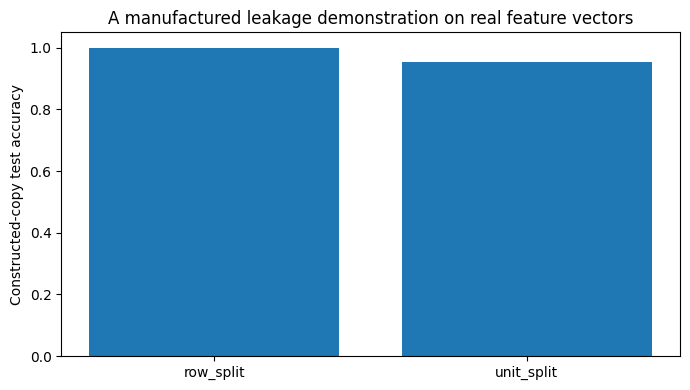

In [4]:
names=list(results);plt.figure(figsize=(7,4))
plt.bar(names,[results[k]['accuracy'] for k in names]);plt.ylim(0,1.05);plt.ylabel('Constructed-copy test accuracy');plt.title('A manufactured leakage demonstration on real feature vectors')
plt.tight_layout();show_and_save(OUT/'split_comparison.png')


## Numerical representation can dominate a raw metric
Multiply the first feature by 1000 as a declared representation change. Training standardization should cancel that positive linear scale change on the same rows; this is an arithmetic test, not an assumed unit definition.

In [5]:
from shape_lab.practice_v7 import fit_scaler,apply_scaler
tr=np.arange(126);te=np.arange(126,210)
c,s=fit_scaler(X[tr]);z=apply_scaler(X[te],c,s)
scaled=X.copy();scaled[:,0]*=1000
c2,s2=fit_scaler(scaled[tr]);z2=apply_scaler(scaled[te],c2,s2)
assert np.allclose(z,z2)
print('Maximum standardized difference:',np.max(np.abs(z-z2)))
print('Raw distance first two rows:',np.linalg.norm(X[0]-X[1]),np.linalg.norm(scaled[0]-scaled[1]))
# This identity demo does not train a classifier on the class-ordered first 126 rows.


Maximum standardized difference: 2.220446049250313e-15
Raw distance first two rows: 1.3335775230559335 380.00215003208865


## Save the construction and its limits
A group ID protects only the grouping it actually represents. There are no available farm identifiers. Synthetic duplicates must remain labeled as such in any presentation.

In [6]:
save_json(OUT/'results.json',{'models':results,'standardized_max_abs_difference':float(np.max(np.abs(z-z2))),'data_role':'observed Seeds vectors, each copied three times in software; NOT 630 observed kernels'})
save_json(OUT/'protocol.json',{'source_numeric_sha256':meta['numeric_sha256'],'copy_rule':'np.repeat(...,3,axis=0)','seed':73,'model':'training StandardScaler + 1-nearest-neighbor','audits':audits,'scope':'illustrative leakage stress test, not estimate of bias in another domain'})
